Shape of data: (6000, 6)
       Intensity   Gradient  LocalMean   LocalStd  Laplacian      Range
count  6000.0000  6000.0000  6000.0000  6000.0000  6000.0000  6000.0000
mean      0.4523     0.4253     0.4549     0.0744     0.1168     0.1639
std       0.2116     0.5107     0.1869     0.0673     0.1636     0.1639
min       0.0157     0.0000     0.0364     0.0000     0.0000     0.0000
25%       0.2863     0.0930     0.3153     0.0241     0.0157     0.0471
50%       0.4353     0.2317     0.4447     0.0524     0.0549     0.1059
75%       0.5922     0.5499     0.5766     0.1059     0.1490     0.2275
max       1.0000     3.3232     1.0000     0.3763     1.3804     0.9176
Outliers detected using Z-Score method (|z| > 3):
Intensity = 0
Gradient = 148
LocalMean = 0
LocalStd = 87
Laplacian = 144
Range = 109
Total rows containing outliers: 290
IQR method boundaries:
Intensity  Q1 = 0.2863  Q3 = 0.5922  IQR = 0.3059  Lower = -0.1725  Upper = 1.051
Gradient  Q1 = 0.093  Q3 = 0.5499  IQR = 0.4569  Lo

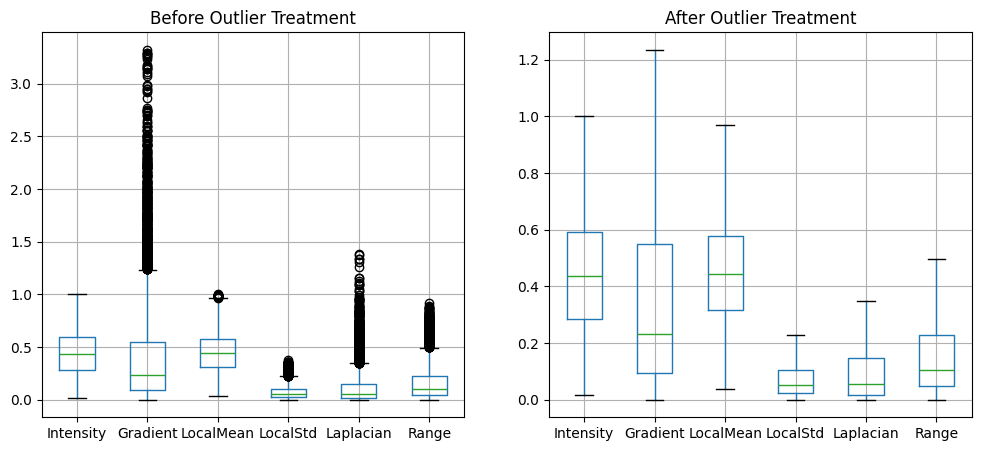

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat
from scipy.ndimage import uniform_filter, sobel, laplace, maximum_filter, minimum_filter
import kagglehub

path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

images = sorted(glob.glob(path + "/**/*.jpg", recursive=True))
gtmap = {}
for m in glob.glob(path + "/**/*.mat", recursive=True):
    gtmap[os.path.basename(m)[:-4]] = m

names = ["Intensity", "Gradient", "LocalMean", "LocalStd", "Laplacian", "Range"]


def get_features(f):
    g = np.array(Image.open(f).convert("L"), dtype=float) / 255.0
    gx = sobel(g, axis=0)
    gy = sobel(g, axis=1)
    grad = np.sqrt(gx * gx + gy * gy)
    mean = uniform_filter(g, 5)
    std = np.sqrt(np.abs(uniform_filter(g * g, 5) - mean * mean))
    lap = np.abs(laplace(g))
    rng = maximum_filter(g, 3) - minimum_filter(g, 3)
    F = np.stack([g, grad, mean, std, lap, rng], axis=2)
    return F.reshape(-1, 6), g.shape


def get_labels(name, shape):
    d = loadmat(gtmap[name])["groundTruth"]
    b = np.zeros(shape)
    for i in range(d.shape[1]):
        b = b + d[0, i]["Boundaries"][0, 0]
    return (b > 0).astype(int).reshape(-1)


def build_dataset(n_images, per_class):
    X = []
    Y = []
    for f in images[:n_images]:
        name = os.path.basename(f)[:-4]
        if name not in gtmap:
            continue
        F, shape = get_features(f)
        L = get_labels(name, shape)
        pos = np.where(L == 1)[0]
        neg = np.where(L == 0)[0]
        k = min(per_class, len(pos), len(neg))
        if k == 0:
            continue
        pos = np.random.choice(pos, k, replace=False)
        neg = np.random.choice(neg, k, replace=False)
        idx = np.concatenate([pos, neg])
        X.append(F[idx])
        Y.append(L[idx])
    return np.vstack(X), np.concatenate(Y)


np.random.seed(1)
X, y = build_dataset(30, 100)
df = pd.DataFrame(X, columns=names)

print("Shape of data:", df.shape)
print(df.describe().round(4))

z = (df - df.mean()) / df.std()
zout = (z.abs() > 3)

print("Outliers detected using Z-Score method (|z| > 3):")
for c in names:
    print(c, "=", int(zout[c].sum()))
print("Total rows containing outliers:", int(zout.any(axis=1).sum()))

q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

print("IQR method boundaries:")
for c in names:
    print(c, " Q1 =", round(q1[c], 4), " Q3 =", round(q3[c], 4), " IQR =", round(iqr[c], 4), " Lower =", round(low[c], 4), " Upper =", round(high[c], 4))

iout = (df < low) | (df > high)
print("Outliers detected using IQR method:")
for c in names:
    print(c, "=", int(iout[c].sum()))
print("Total rows containing outliers:", int(iout.any(axis=1).sum()))

df_removed = df[~iout.any(axis=1)]
print("Rows before removal:", len(df), " Rows after removal:", len(df_removed))

df_capped = df.clip(lower=low, upper=high, axis=1)
print("Data after capping (Winsorization):")
print(df_capped.describe().round(4))

print("Comparison of Mean and Std before and after treatment:")
for c in names:
    print(c, " Before Mean =", round(df[c].mean(), 4), " After Mean =", round(df_capped[c].mean(), 4), " Before Std =", round(df[c].std(), 4), " After Std =", round(df_capped[c].std(), 4))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(ax=ax[0])
ax[0].set_title("Before Outlier Treatment")
df_capped.boxplot(ax=ax[1])
ax[1].set_title("After Outlier Treatment")
plt.show()
